# 12. Learned embeddings

Every other page here measures cells with CellProfiler: named features, one per shape or intensity or texture,
in a `var` that says which compartment and which channel each came from. A learned embedding replaces that
block with the output of a neural network — a few hundred numbers per well that mean nothing individually.

mantispy does not care. `X` is a matrix, and normalization, hit calling, consensus and the metrics all run on
one as readily as the other. What changes is the recipe around it, and what you can no longer ask.

This page uses JUMP-Lite {cite:p}`Munoz_2026`, which is built for exactly this comparison: four plates of the
JUMP Target-2 plate map, one from each of four laboratories, with **the same 1,536 wells** measured six ways —
five learned embeddings and one CellProfiler-equivalent feature set. The rows and the metadata are identical
across all six, so swapping the feature block is a controlled experiment rather than a change of dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

adata = mt.ds.jump_lite("openphenom")
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/5rhSExnd/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 1536 × 384
    obs: 'Metadata_id', 'Metadata_Source', 'Metadata_Batch', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site', 'Metadata_model', 'Metadata_dataset', 'Metadata_compression', 'Metadata_CellCount', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

384 numbers per well from OpenPhenom, a Cell Painting foundation model. The metadata is ordinary JUMP
metadata — source, batch, plate, well, and the compound each well received.

The four batches are four different laboratories running one plate map, which makes this a batch-correction
problem with a clean design: whatever separates `source_3` from `source_6` is not biology, because they
received the same compounds in the same wells.

In [2]:
counts = (
    adata.obs.groupby("Metadata_Source", observed=True)
    .agg(plates=("Metadata_Plate", "nunique"), wells=("Metadata_Well", "size"), controls=("Metadata_Control", "sum"))
)
counts["compounds"] = adata.obs.groupby("Metadata_Source", observed=True)["Metadata_Perturbation"].nunique()
counts

,plates,wells,controls,compounds
Metadata_Source,,,,
source_3,1,384,64,302
source_4,1,384,64,302
source_5,1,384,64,302
source_6,1,384,64,302


## What `var` no longer tells you

A CellProfiler feature name parses into a compartment, a feature group and a channel. `openphenom_nahualX_17`
parses into nothing, so the annotation columns the schema requires are present and empty.

In [3]:
adata.var.head(3)

,object,feature_group,feature,channel,scale,angle,gray_levels,radial_bin,params,is_feature
openphenom_nahualX_0,openphenom,nahualX,nahualX,NaN,0.0,NaN,NaN,NaN,0,True
openphenom_nahualX_1,openphenom,nahualX,nahualX,NaN,1.0,NaN,NaN,NaN,1,True
openphenom_nahualX_10,openphenom,nahualX,nahualX,NaN,10.0,NaN,NaN,NaN,10,True


This is not a defect, it is the honest answer: the embedding has no notion of a channel or a compartment. The
consequence is that anything keyed on the feature annotation has nothing to work with. `pl.effect_sizes`
colours its bars by feature family, `tl.feature_sets` groups features into sets, and the CellProfiler
blocklist names features to drop — none of them apply here.

What survives is everything that treats a feature as an anonymous number: normalization, sphering, distances,
hit calling, consensus, and every metric.

## Bringing your own embedding

`ds.jump_lite` is a convenience. An embedding you produced yourself is a matrix and a metadata frame, and
`io.stamp` is what puts it on the mantispy API surface.

In [4]:
import anndata as ad

# Pretend this came out of your own model, one row per well.
values = np.asarray(adata.X)[:8]
metadata = adata.obs[["Metadata_Plate", "Metadata_Well", "Metadata_Perturbation", "Metadata_Control"]][:8]

mine = ad.AnnData(values, obs=metadata.copy())
mine.var_names = [f"mymodel_{index}" for index in range(values.shape[1])]
mt.io.stamp(mine, resolution="well")
mt.io.validate(mine)

ValidationReport(ok=True, errors=0, warnings=1)

`io.stamp` fills the annotation columns by parsing the feature names — which for an embedding means filling
them with nothing — and records the resolution, so the object validates and can be written to h5ad. It refuses
a resolution whose required `obs` columns are missing rather than letting the failure surface three calls later.

## The recipe

Two things change against the CellProfiler pipeline.

**Normalize as usual.** The embedding is the model's raw output on each well's images: it carries the plate's
staining and illumination just as CellProfiler features do, so a per-plate normalization against the negative
controls is still the first step. The degenerate-scale check still applies, and here it is worth running for
what it reports rather than what it drops: none of these embedding dimensions is constant among a plate's
controls, while the `cp_measure` feature set below has more than a hundred features that are.

**Do not select features.** Variance and correlation filters assume features are interpretable measurements
that can be dropped individually. The dimensions of an embedding are a basis, not a list of measurements;
dropping some of them because they correlate discards the geometry the model learned.

In [5]:
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
degenerate = int(adata.var["degenerate_scale"].sum())
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
f"dropped {degenerate} degenerate dimension(s), {adata.n_vars} left"

'dropped 0 degenerate dimension(s), 384 left'

## Comparing six feature sets

The interesting question is not whether an embedding works, but how it compares with the alternatives on the
same wells. Two readouts, both of which the package computes:

- **`metrics.known_relationships`** — of the compounds annotated to act on the same gene, how many end up in
  either tail of the similarity distribution? A map with no information recovers 10%.
- **`tl.percent_replicating`** — does a compound's profile match its own replicates, run at another laboratory?

They measure different things, and as the table below shows they do not have to agree.

In [6]:
targets = mt.ds.jump_lite_targets()
f"{targets['source'].nunique()} genes over {targets['target'].nunique()} compounds"

'1300 genes over 1526 compounds'

In [7]:
def prepared(model):
    """Load one feature set, normalize it on the controls, and drop what cannot be normalized."""
    wells = mt.ds.jump_lite(model)
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    wells = wells[:, ~wells.var["degenerate_scale"].to_numpy()].copy()
    if np.isnan(np.asarray(wells.X)).any():  # cp_measure carries features that are missing outright
        mt.pp.feature_select(wells, operations=("drop_na_columns",), na_cutoff=0.0)
        wells = mt.pp.subset_features(wells)
    sc.pp.pca(wells, n_comps=50)
    mt.pp.tvn(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_tvn")
    return wells


def scored(wells, rep):
    """Target recall on consensus profiles, and replicate retrieval on wells."""
    treated = ~wells.obs["Metadata_Control"].to_numpy()
    profiles = ad.AnnData(np.asarray(wells.obsm[rep], dtype=np.float32)[treated], obs=wells.obs[treated].copy())
    mt.io.stamp(profiles, resolution="well")
    recall = mt.metrics.known_relationships(mt.tl.consensus(profiles, method="median", min_replicates=1), targets)

    mt.tl.percent_replicating(profiles, groupby="Metadata_Perturbation", use_rep=None, null_size=2000, seed=0)
    replicating = profiles.uns["mantispy"]["percent_replicating"]["is_replicating"].mean()
    return float(recall["value"].iloc[0]), float(replicating)


rows = []
for model in mt.ds.JUMP_LITE_MODELS:
    wells = prepared(model)
    for rep in ("X_pca", "X_tvn"):
        recall, replicating = scored(wells, rep)
        rows.append({"model": model, "alignment": rep, "dims": wells.n_vars,
                     "target recall": recall, "percent replicating": replicating})

comparison = pd.DataFrame(rows)
comparison.pivot(index="model", columns="alignment", values=["target recall", "percent replicating"]).round(3)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_94060/3324476553.py:4: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_94060/3324476553.py:4: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they 

target recall        percent replicating       
alignment             X_pca  X_tvn               X_pca  X_tvn
model                                                        
cp_measure            0.030  0.127               0.409  0.339
dinov2                0.052  0.104               0.439  0.355
dinov2_random         0.114  0.087               0.080  0.106
morphem               0.069  0.136               0.392  0.399
openphenom            0.057  0.127               0.352  0.316
subcell               0.042  0.154               0.435  0.329

Three things to read out of that table.

**The untrained model behaves like one.** `dinov2_random` is the same architecture with random weights, and it
is the control for this whole comparison: its replicate retrieval collapses, because random projections of an
image do not reproduce across laboratories. Its target recall sits near the 10% baseline. Any pipeline that
reports a trained model doing no better than this one has a bug, not a finding.

**Alignment and replication pull in opposite directions.** `pp.tvn` raises target recall on every trained
feature set, and lowers replicate retrieval on all but one. Whitening each batch by its own controls' covariance
moves the batches onto each other, and in doing so it stretches the low-variance directions where replicate
agreement lives. Which readout you optimize is a decision about what the screen is for, not a default.

**The CellProfiler-equivalent set is not behind.** `cp_measure` is competitive with the learned models on both
readouts here. The independent benchmark of these six reaches the same conclusion {cite:p}`Munoz_2026`: on
Cell Painting, classical features remain a strong baseline, and the case for an embedding is throughput and the
absence of a segmentation step rather than a large accuracy gain.

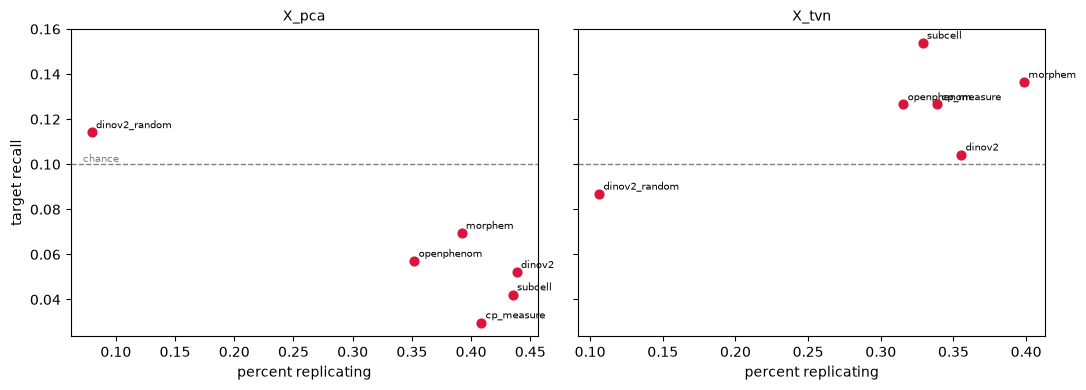

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, alignment in zip(axes, ("X_pca", "X_tvn"), strict=True):
    block = comparison[comparison["alignment"] == alignment].set_index("model")
    ax.scatter(block["percent replicating"], block["target recall"], s=40, color="crimson")
    for model, row in block.iterrows():
        ax.annotate(model, (row["percent replicating"], row["target recall"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
    ax.axhline(0.10, color="grey", ls="--", lw=1)
    ax.set_title(alignment, fontsize=10)
    ax.set_xlabel("percent replicating")
axes[0].set_ylabel("target recall")
axes[0].text(0.02, 0.10, " chance", fontsize=7, color="grey", va="bottom", transform=axes[0].get_yaxis_transform())
fig.tight_layout()
plt.show()

The dashed line is the 10% a map with no information recovers. Without alignment every trained model sits on or
under it; with alignment they clear it, and the spread along the x-axis is the price.

## Do the laboratories still separate?

`metrics.pc_regression` asks how much of the variance the source explains. It is worth checking before and after,
because a correction that leaves the batch structure intact has done nothing, and one that removes it may have
removed the biology with it — which is why the table above matters more than this number.

In [9]:
wells = prepared("openphenom")
pd.concat([
    mt.metrics.pc_regression(wells, key="Metadata_Source", use_rep="X_pca"),
    mt.metrics.pc_regression(wells, key="Metadata_Source", use_rep="X_tvn"),
])[["representation", "value"]]

,representation,value
0,X_pca,0.034878
0,X_tvn,0.035874


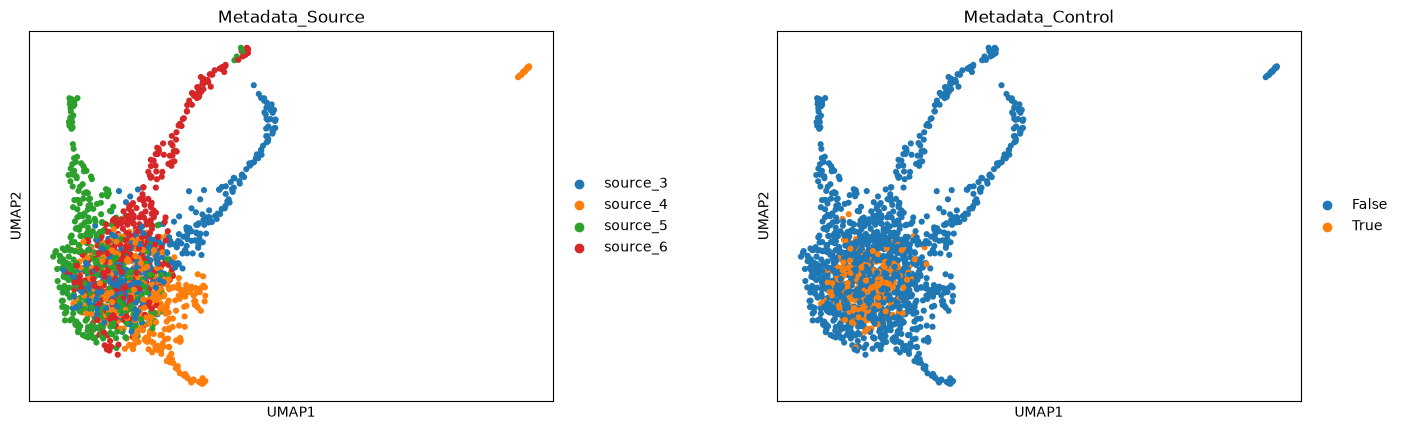

In [10]:
sc.pp.neighbors(wells, use_rep="X_tvn")
sc.tl.umap(wells)
sc.pl.umap(wells, color=["Metadata_Source", "Metadata_Control"], wspace=0.3)

A scanpy UMAP works here exactly as it does on CellProfiler profiles — the object is an ordinary `AnnData`, and
`X_tvn` is an ordinary `obsm` entry.

## Summary

- An embedding is a feature matrix. Normalization, distances, hit calling, consensus and every metric work on
  it unchanged; `io.stamp` brings one you produced yourself onto the API surface.
- `var` carries no compartment or channel, so feature families, feature sets and the blocklist do not apply.
  Read that as the embedding declining to answer, not as missing data.
- Normalize per plate against the controls as usual. Do not feature-select: the dimensions are a basis, not a
  list of measurements.
- Keep an untrained model in the comparison. It is the cheapest check that the pipeline measures anything.
- Batch alignment and replicate agreement trade against each other. Decide which the screen needs, and measure
  both.

Next: back to [8. Trustworthy features and experimental design](08_trustworthy_features_and_design.ipynb) for
the rest of the benchmarking vocabulary, or [4. Correcting and evaluating](04_correcting_and_evaluating.ipynb)
for the batch-correction methods this page compared TVN against.